# 第6回Pythonセミナー課題: PCA・UMAP・クラスタリング

このノートブックでは `MNICT_train.csv` を使い、以下を行います。

- PCA による可視化
- PCA の寄与率 vs 累積寄与率のプロット
- PC1〜PC10 の 10×10 プロット
- UMAP による可視化
- 階層的クラスタリングとデンドログラム
- k-means による非階層的クラスタリング
- クラスタリング結果を PCA の図に併記

データ数が 60,000 件と多いため、UMAP とクラスタリングは代表サンプル 2,000 件で行います。デンドログラムは見やすさのため、その中から 200 件を使って表示します。

## 0. 必要なライブラリの準備

このフォルダは `uv` プロジェクトとして設定済みです。ターミナルで次のように起動して、このノートブックを開いてください。

```bash
uv run jupyter lab
```

もし環境を作り直す場合は、先に `uv sync` を実行してください。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap.umap_ as umap
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["font.size"] = 12
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 0
N_SAMPLE = 2000
N_DENDROGRAM = 200
N_CLUSTERS = 10

/Users/f-kazuma/Developer/Python_seminer/6th/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. データの読み込みと前処理

`MNICT_train.csv` は先頭列がインデックス、残り 784 列がピクセル値です。PCA、UMAP、クラスタリングでは、各特徴量を平均 0、標準偏差 1 に標準化してから使います。

In [2]:
data_path = Path("MNICT_train.csv")
if not data_path.exists():
    data_path = Path("/Users/f-kazuma/Developer/Python_seminer/6th/MNICT_train.csv")

dataset = pd.read_csv(data_path, index_col=0)
dataset = dataset.apply(pd.to_numeric)

print("dataset shape:", dataset.shape)
display(dataset.head())

dataset shape: (60000, 784)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
sample_size = min(N_SAMPLE, len(dataset))
x = dataset.sample(n=sample_size, random_state=RANDOM_STATE)

scaler = StandardScaler()
autoscaled_x = pd.DataFrame(
    scaler.fit_transform(x),
    index=x.index,
    columns=x.columns,
)

print("sample shape:", x.shape)
display(autoscaled_x.iloc[:5, :10])

sample shape: (2000, 784)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9
3048,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19563,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58303,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8870,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. PCA による可視化

PCA は多変量データの分散が大きい方向を順番に見つけ、少数の主成分でデータを表す手法です。ここでは第1主成分 PC1 と第2主成分 PC2 を使って2次元に可視化します。

In [4]:
pca = PCA()
pca_score_array = pca.fit_transform(autoscaled_x)

pca_scores = pd.DataFrame(
    pca_score_array,
    index=autoscaled_x.index,
    columns=[f"PC{i + 1}" for i in range(pca_score_array.shape[1])],
)

explained_ratio = pca.explained_variance_ratio_
cumulative_ratio = np.cumsum(explained_ratio)

display(pca_scores.iloc[:5, :10])

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
3048,-5.731596,-0.832473,3.810842,2.731018,-0.969585,-4.689033,-0.521548,0.514392,-0.822363,-1.212202
19563,8.083864,-0.559296,5.004124,-12.848533,12.000594,-3.039549,1.763117,4.384030,1.466203,3.855488
58303,-6.606666,-3.853933,1.744387,-6.234097,-1.200274,1.901249,-4.082102,0.979370,3.225971,2.227037
8870,2.946685,1.939938,1.915766,-10.436259,6.009653,-4.553569,0.844871,1.152172,-2.637244,-1.176686
40228,10.486601,-8.446897,-4.991325,-2.762758,-9.068948,-7.483946,0.367701,-1.712155,4.422336,-2.101108


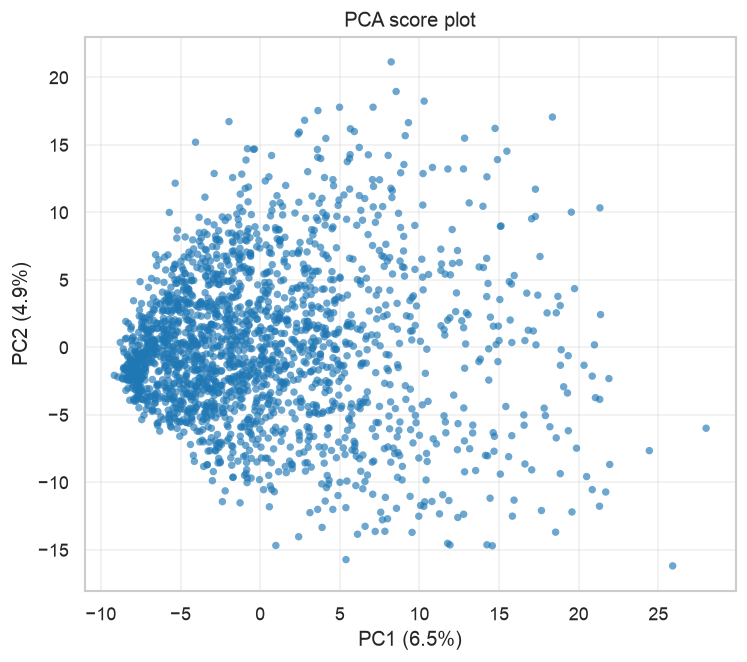

In [5]:
plt.figure(figsize=(7, 6))
ax = sns.scatterplot(
    data=pca_scores,
    x="PC1",
    y="PC2",
    s=20,
    alpha=0.65,
    color="tab:blue",
    edgecolor="none",
)
ax.set_xlabel(f"PC1 ({explained_ratio[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained_ratio[1] * 100:.1f}%)")
ax.set_title("PCA score plot")
ax.grid(alpha=0.3)
plt.show()

## 3. PCA の寄与率 vs 累積寄与率

寄与率は各主成分が元データの分散をどれだけ説明しているかを表します。累積寄与率は、PC1 から順に足し合わせた説明割合です。

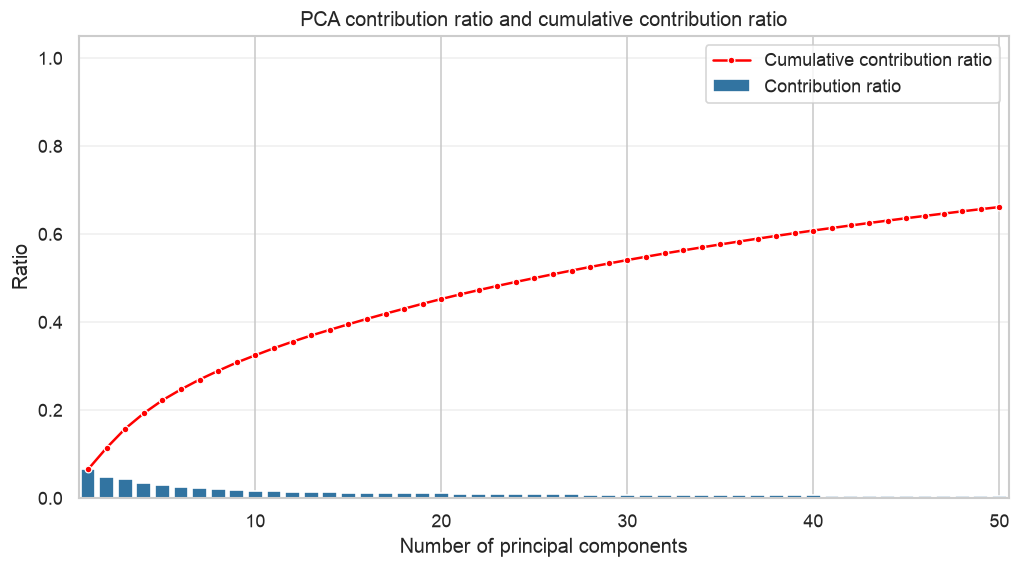

,contribution_ratio,cumulative_contribution_ratio
PC1,0.065234,0.065234
PC2,0.049043,0.114277
PC3,0.043484,0.157761
PC4,0.035002,0.192762
PC5,0.029623,0.222385
PC6,0.024648,0.247033
PC7,0.022416,0.269450
PC8,0.019882,0.289332
PC9,0.018837,0.308169
PC10,0.016540,0.324708


In [6]:
n_components_to_plot = min(50, len(explained_ratio))
cont_plot_table = pd.DataFrame(
    {
        "component": np.arange(1, n_components_to_plot + 1),
        "contribution_ratio": explained_ratio[:n_components_to_plot],
        "cumulative_contribution_ratio": cumulative_ratio[:n_components_to_plot],
    }
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=cont_plot_table,
    x="component",
    y="contribution_ratio",
    color="tab:blue",
    errorbar=None,
    native_scale=True,
    label="Contribution ratio",
)
sns.lineplot(
    data=cont_plot_table,
    x="component",
    y="cumulative_contribution_ratio",
    color="red",
    marker="o",
    markersize=4,
    ax=ax,
    label="Cumulative contribution ratio",
)
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Ratio")
ax.set_title("PCA contribution ratio and cumulative contribution ratio")
ax.set_xlim(0.5, n_components_to_plot + 0.5)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.show()

cont_table = pd.DataFrame(
    {
        "contribution_ratio": explained_ratio,
        "cumulative_contribution_ratio": cumulative_ratio,
    },
    index=[f"PC{i + 1}" for i in range(len(explained_ratio))],
)
display(cont_table.head(20))

## 4. PC1〜PC10 の 10×10 プロット

PC1 から PC10 までの組み合わせを散布図行列で確認します。対角線には各主成分スコアのヒストグラムを表示します。

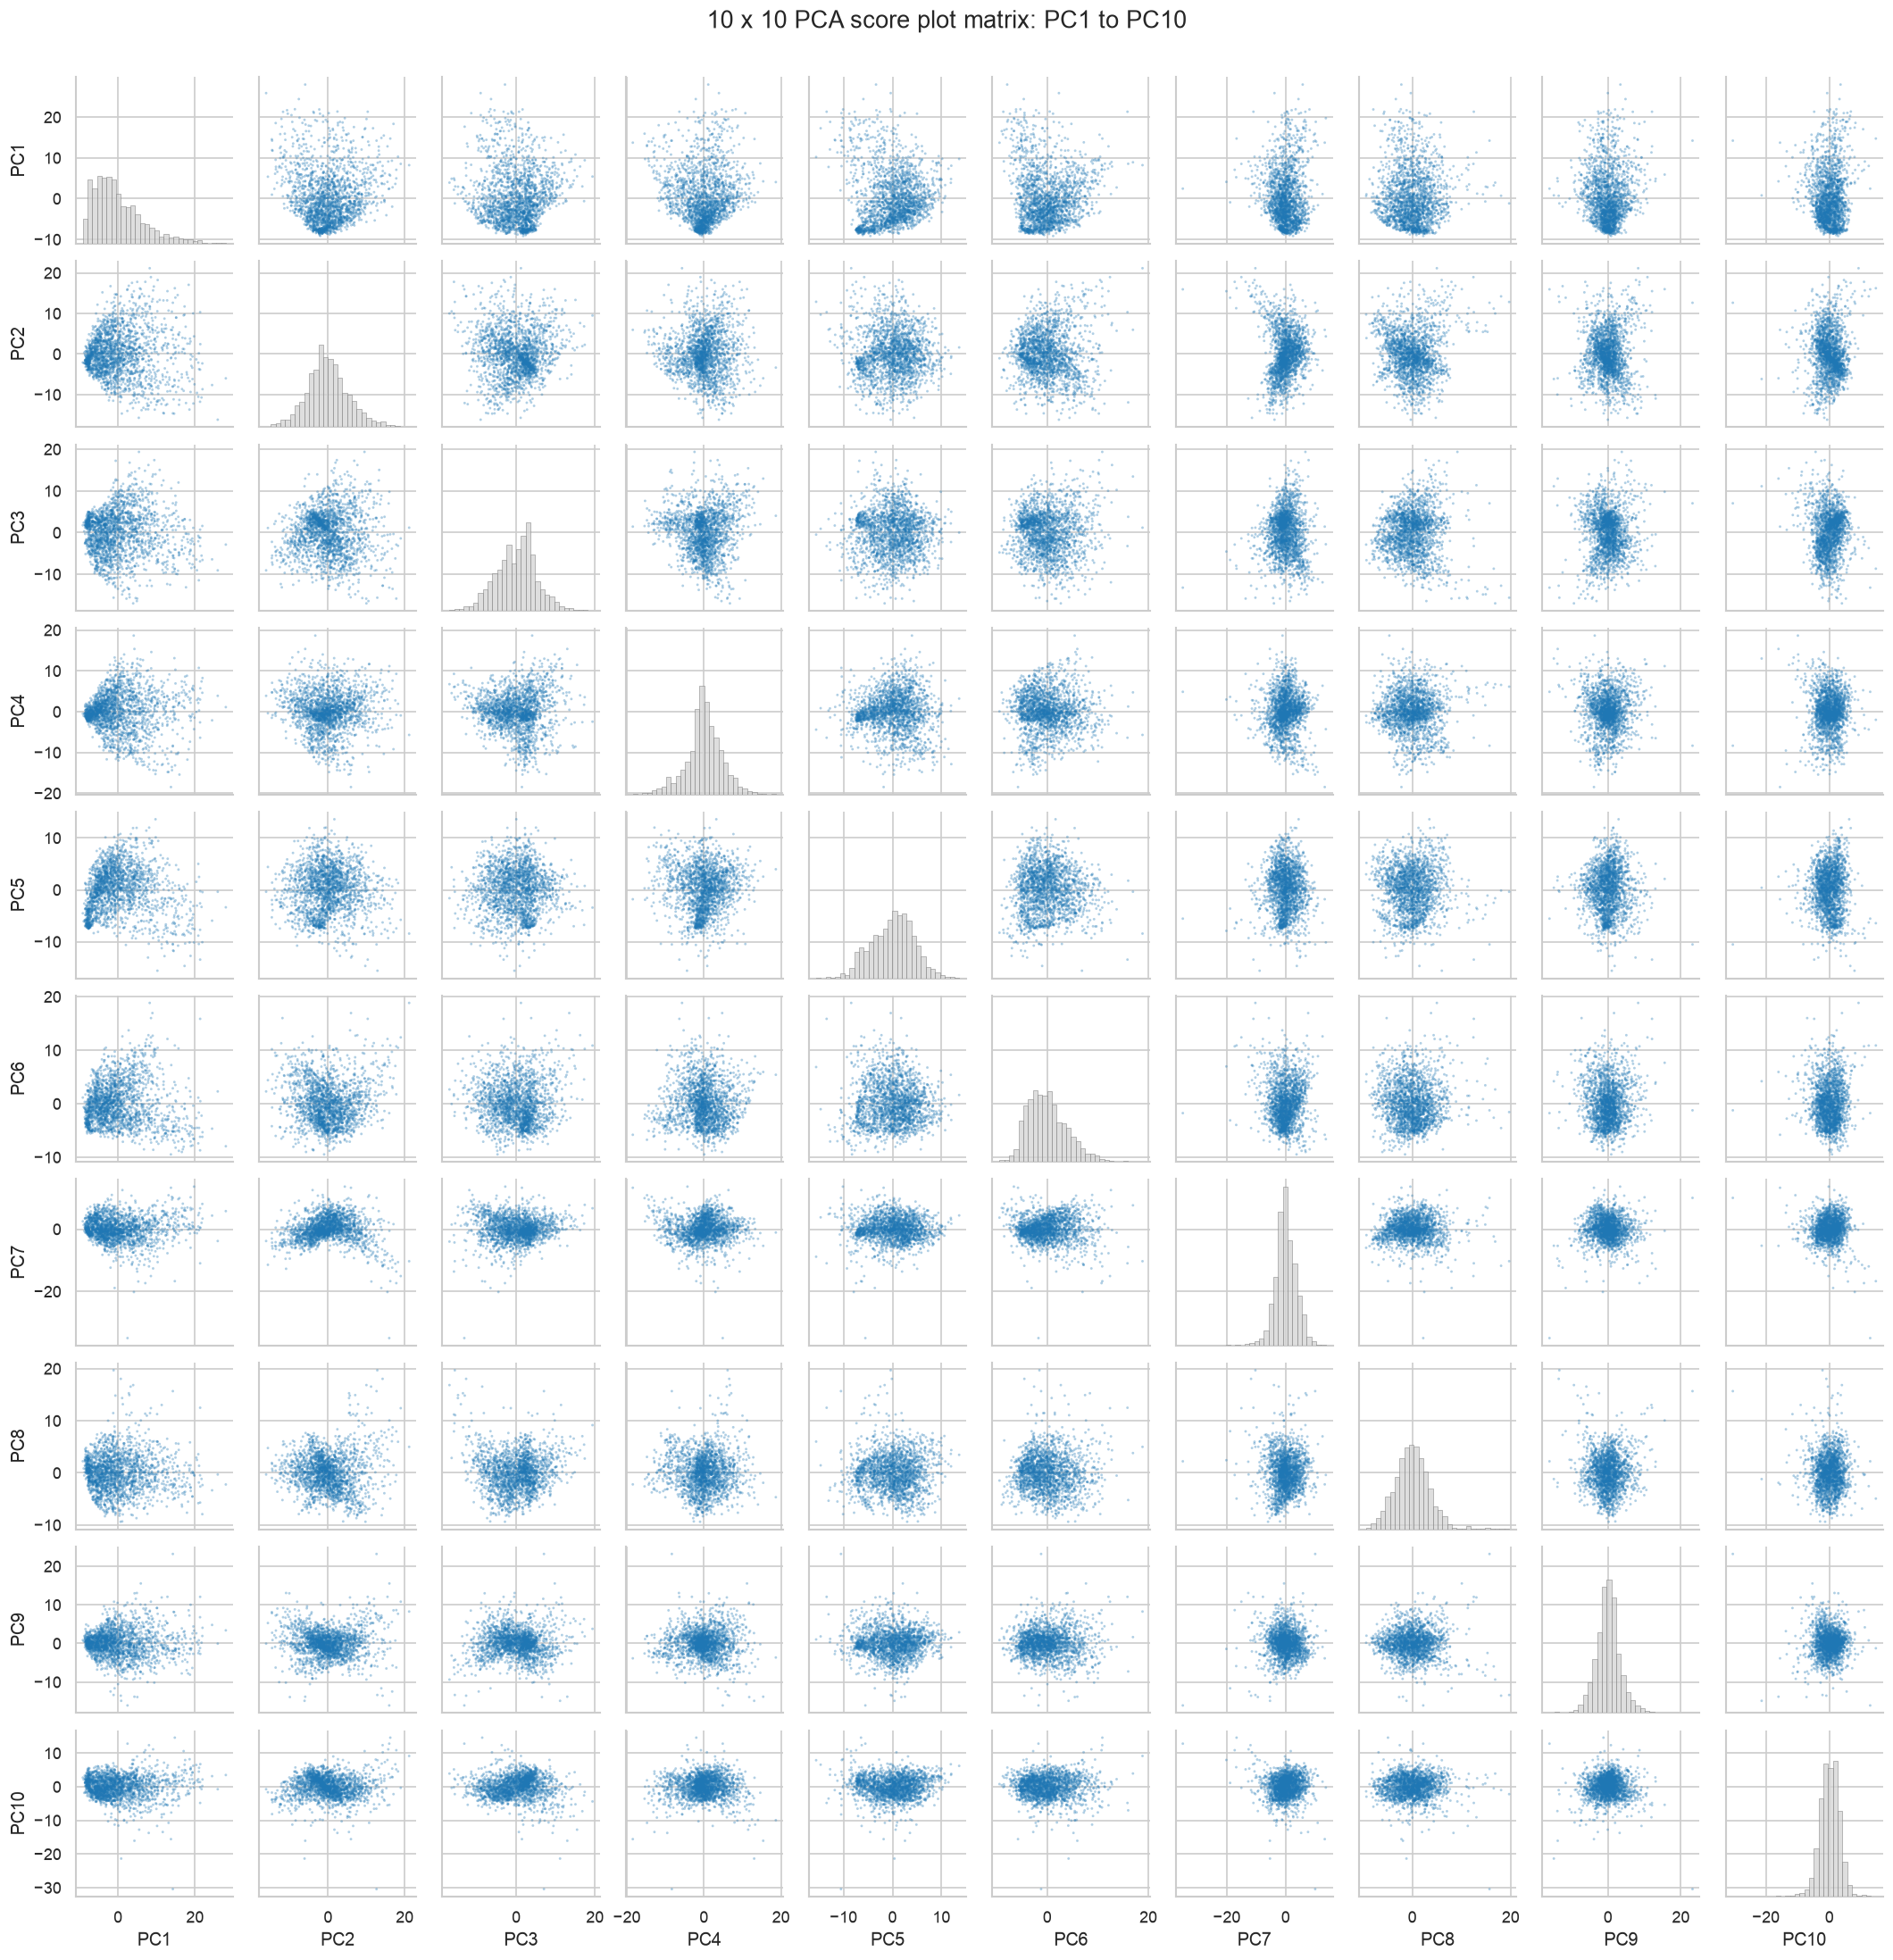

In [7]:
pcs_to_plot = [f"PC{i}" for i in range(1, 11)]

pair_grid = sns.pairplot(
    pca_scores[pcs_to_plot],
    vars=pcs_to_plot,
    diag_kind="hist",
    height=1.8,
    aspect=1,
    plot_kws={"s": 3, "alpha": 0.35, "color": "tab:blue", "edgecolor": "none"},
    diag_kws={"bins": 30, "color": "lightgray", "edgecolor": "gray"},
)
pair_grid.fig.suptitle("10 x 10 PCA score plot matrix: PC1 to PC10", y=1.02, fontsize=16)
plt.show()

## 5. UMAP による可視化

UMAP は近いサンプル同士の関係をなるべく保ちながら、低次元に埋め込む可視化手法です。PCAよりも非線形な構造を見つけやすいことがあります。

/Users/f-kazuma/Developer/Python_seminer/6th/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


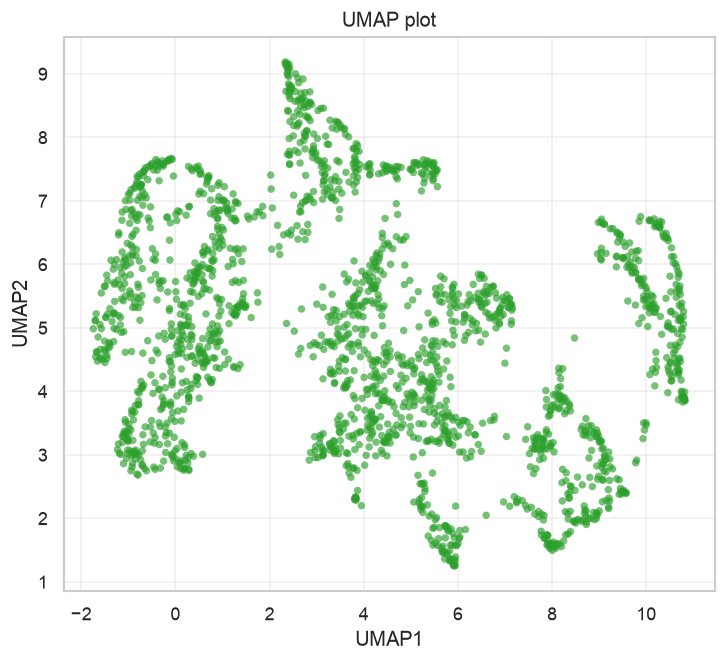

In [8]:
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=RANDOM_STATE,
)
umap_embedding = umap_model.fit_transform(autoscaled_x)

umap_scores = pd.DataFrame(
    umap_embedding,
    index=autoscaled_x.index,
    columns=["UMAP1", "UMAP2"],
)

plt.figure(figsize=(7, 6))
ax = sns.scatterplot(
    data=umap_scores,
    x="UMAP1",
    y="UMAP2",
    s=20,
    alpha=0.65,
    color="tab:green",
    edgecolor="none",
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP plot")
ax.grid(alpha=0.3)
plt.show()

## 6. 階層的クラスタリングとデンドログラム

階層的クラスタリングは、サンプル同士の距離をもとに近いものから順にまとめていく手法です。ここではユークリッド距離とウォード法を用います。

In [9]:
hierarchical_result = linkage(autoscaled_x, metric="euclidean", method="ward")
hierarchical_clusters = pd.Series(
    fcluster(hierarchical_result, N_CLUSTERS, criterion="maxclust"),
    index=autoscaled_x.index,
    name="hierarchical_cluster",
)

print("Hierarchical clustering cluster counts")
display(hierarchical_clusters.value_counts().sort_index().to_frame("count"))

Hierarchical clustering cluster counts


,count
hierarchical_cluster,
1,120
2,446
3,191
4,91
5,352
6,175
7,203
8,382
9,39


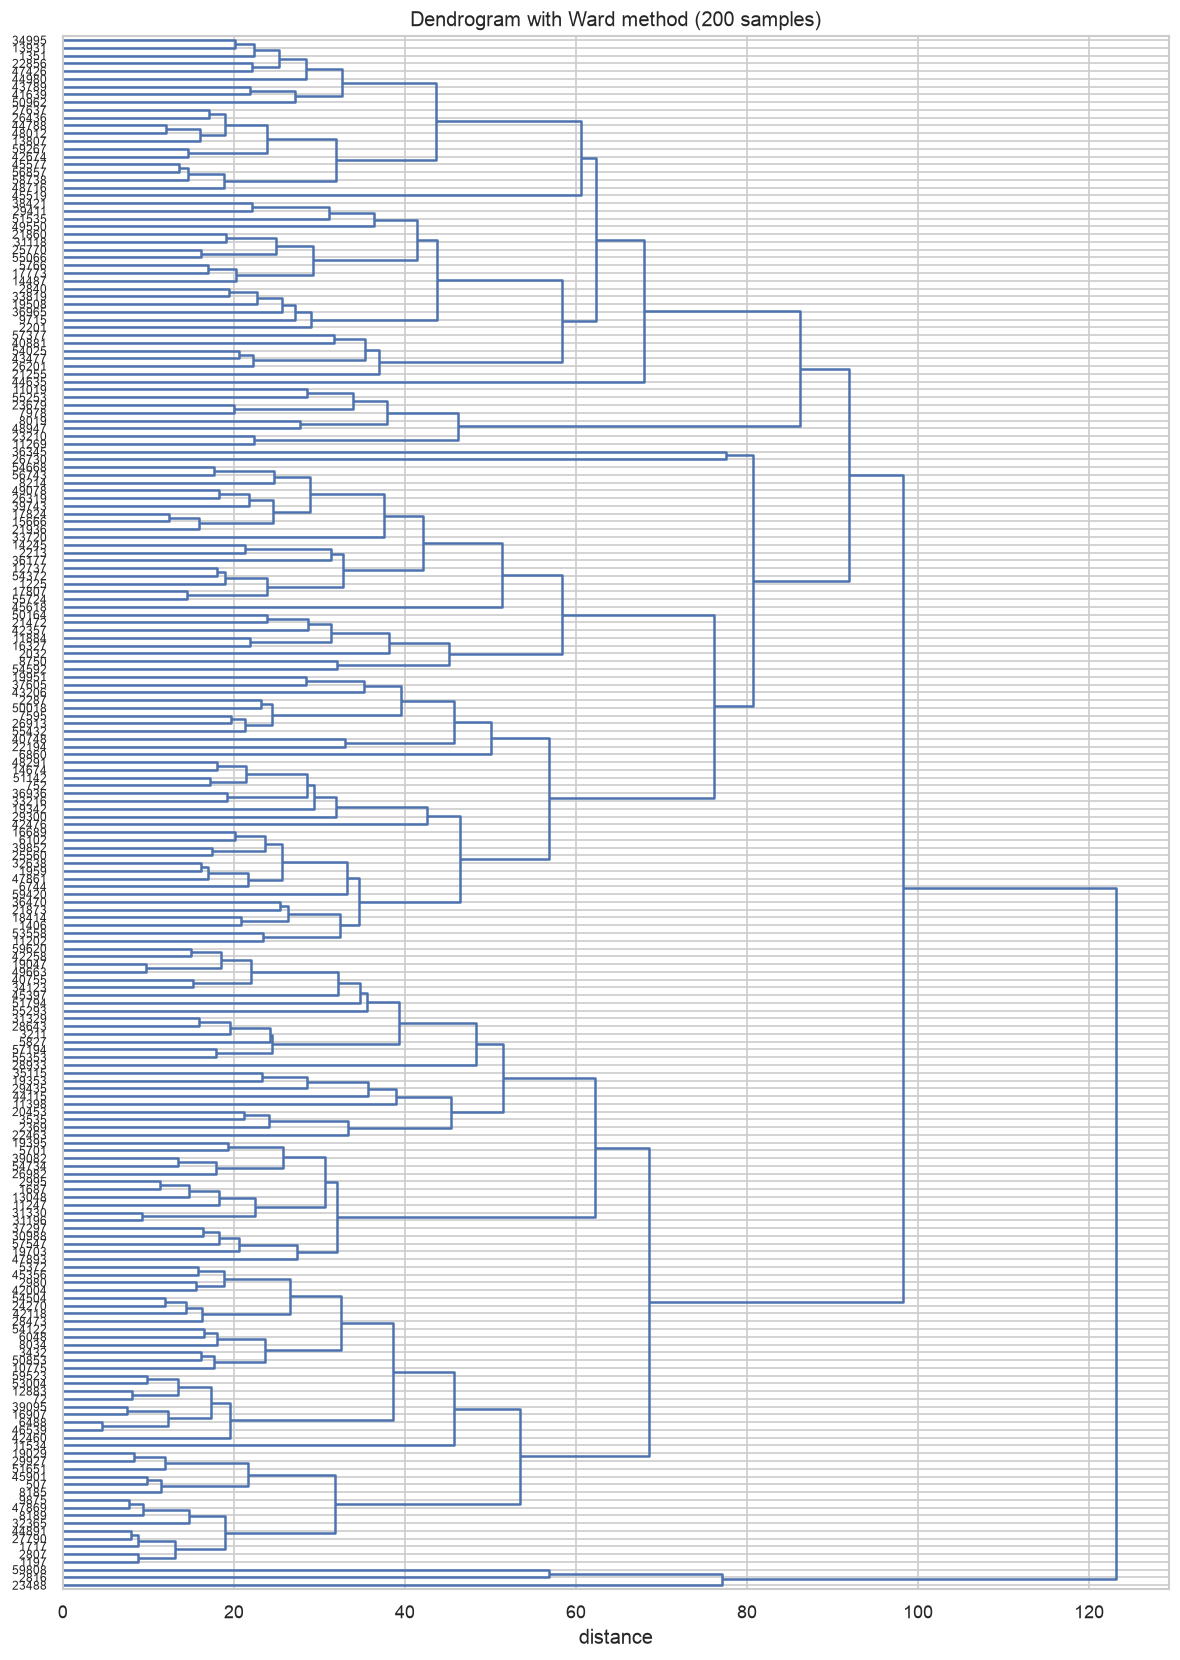

In [10]:
dendrogram_size = min(N_DENDROGRAM, len(autoscaled_x))
dendrogram_x = autoscaled_x.sample(n=dendrogram_size, random_state=RANDOM_STATE)
dendrogram_result = linkage(dendrogram_x, metric="euclidean", method="ward")

plt.figure(figsize=(10, 14))
dendrogram(
    dendrogram_result,
    labels=dendrogram_x.index.astype(str).tolist(),
    orientation="right",
    leaf_font_size=7,
    color_threshold=0,
)
plt.xlabel("distance")
plt.title(f"Dendrogram with Ward method ({dendrogram_size} samples)")
plt.tight_layout()
plt.show()

## 7. k-means による非階層的クラスタリング

k-means は、あらかじめ指定したクラスタ数 k にデータを分ける非階層的クラスタリング手法です。ここでは数字データを想定して 10 クラスタに分けます。

In [11]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
kmeans_clusters = pd.Series(
    kmeans.fit_predict(autoscaled_x) + 1,
    index=autoscaled_x.index,
    name="kmeans_cluster",
)

print("k-means cluster counts")
display(kmeans_clusters.value_counts().sort_index().to_frame("count"))

k-means cluster counts


,count
kmeans_cluster,
1,237
2,332
3,113
4,255
5,294
6,383
7,157
8,1
9,130


## 8. クラスタリング結果を PCA の図に併記

PCA の PC1-PC2 平面上で、階層的クラスタリングと k-means のクラスタ番号を色で表示します。

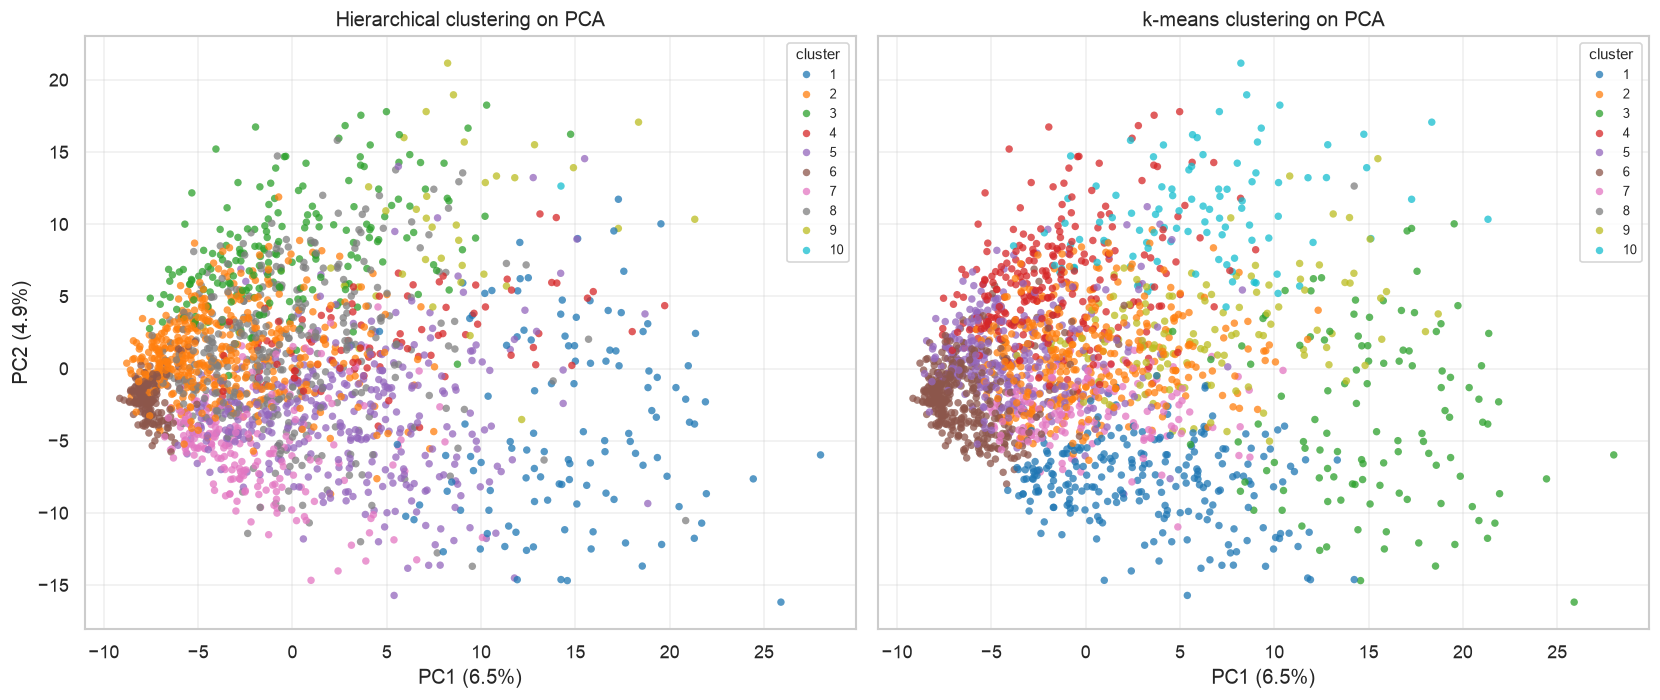

In [12]:
cluster_plot_data = pca_scores[["PC1", "PC2"]].copy()
cluster_categories = [str(i) for i in range(1, N_CLUSTERS + 1)]
cluster_plot_data["hierarchical_cluster"] = pd.Categorical(
    hierarchical_clusters.loc[pca_scores.index].astype(str),
    categories=cluster_categories,
    ordered=True,
)
cluster_plot_data["kmeans_cluster"] = pd.Categorical(
    kmeans_clusters.loc[pca_scores.index].astype(str),
    categories=cluster_categories,
    ordered=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

sns.scatterplot(
    data=cluster_plot_data,
    x="PC1",
    y="PC2",
    hue="hierarchical_cluster",
    palette="tab10",
    s=20,
    alpha=0.75,
    edgecolor="none",
    ax=axes[0],
)
axes[0].set_title("Hierarchical clustering on PCA")
axes[0].set_xlabel(f"PC1 ({explained_ratio[0] * 100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({explained_ratio[1] * 100:.1f}%)")
axes[0].grid(alpha=0.3)
axes[0].legend(title="cluster", fontsize=8, title_fontsize=9, loc="best")

sns.scatterplot(
    data=cluster_plot_data,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab10",
    s=20,
    alpha=0.75,
    edgecolor="none",
    ax=axes[1],
)
axes[1].set_title("k-means clustering on PCA")
axes[1].set_xlabel(f"PC1 ({explained_ratio[0] * 100:.1f}%)")
axes[1].grid(alpha=0.3)
axes[1].legend(title="cluster", fontsize=8, title_fontsize=9, loc="best")

plt.tight_layout()
plt.show()

In [13]:
result_table = pd.concat(
    [
        pca_scores.iloc[:, :10],
        umap_scores,
        hierarchical_clusters,
        kmeans_clusters,
    ],
    axis=1,
)

display(result_table.head())
result_table.to_csv("mnict_pca_umap_cluster_results.csv")
cont_table.to_csv("mnict_pca_contribution_ratios.csv")

print("Saved: mnict_pca_umap_cluster_results.csv")
print("Saved: mnict_pca_contribution_ratios.csv")

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,UMAP1,UMAP2,hierarchical_cluster,kmeans_cluster
3048,-5.731596,-0.832473,3.810842,2.731018,-0.969585,-4.689033,-0.521548,0.514392,-0.822363,-1.212202,4.911773,4.442454,8,6
19563,8.083864,-0.559296,5.004124,-12.848533,12.000594,-3.039549,1.763117,4.384030,1.466203,3.855488,10.708037,5.149680,4,7
58303,-6.606666,-3.853933,1.744387,-6.234097,-1.200274,1.901249,-4.082102,0.979370,3.225971,2.227037,9.392814,6.351095,5,6
8870,2.946685,1.939938,1.915766,-10.436259,6.009653,-4.553569,0.844871,1.152172,-2.637244,-1.176686,10.682534,5.115672,4,7
40228,10.486601,-8.446897,-4.991325,-2.762758,-9.068948,-7.483946,0.367701,-1.712155,4.422336,-2.101108,8.938840,1.996627,1,3


Saved: mnict_pca_umap_cluster_results.csv
Saved: mnict_pca_contribution_ratios.csv


## 9. 教師あり学習と教師なし学習の違い

- 教師あり学習: 正解ラベルを使って、入力から正解を予測するモデルを作る方法です。例として、画像から数字ラベルを予測する分類があります。
- 教師なし学習: 正解ラベルを使わず、データの構造や似ているグループを見つける方法です。今回の PCA、UMAP、階層的クラスタリング、k-means は教師なし学習に含まれます。
- PCA と UMAP は主に可視化や次元削減に使われ、クラスタリングは似たサンプルをグループ分けするために使われます。